<a href="https://colab.research.google.com/github/dayananathalih-prog/EstadisticaVerano2026/blob/main/PROBLEMARIOS/PROBLEMARIOU4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dayana Nathali Hernandez Hernandez

##Analiza los siguientes diseños experimentales, e intenta sacar el máximo valor a la información. Verifica los supuestos (linealidad, homscedasticidad e independencia), puedes apoyarte en [este documento](https://colab.research.google.com/drive/1VDWeVo0mZluvDAFcr5Vq6n3EdqW3EZaG?usp=sharing). Aplica una prueba post-hoc en caso que sea necesario. Redacta una conclusión y una recomendación para las personas que recolectaron los datos.

1. **Comparación de cuatro métodos de ensamble:** Un equipo de mejora investiga el efecto de cuatro métodos de ensamble A, B, C y D, sobre el tiempo de ensamble en minutos. En primera instancia, la estrategia experimental es aplicar cuatro veces los cuatro métodos de ensamble en orden completamente aleatorio (las 16 pruebas en orden aleatorio). Los tiempos de ensamble obtenidos se muestran en la tabla 3.1. Si se usa el diseño completamente al azar (DCA), se supone que, además del método de ensamble, no existe ningún otro factor que influya de manera significativa sobre la variable de respuesta (tiempo de ensamble).

| Método de ensamble | A  | B  | C  | D  |
|--------------------|----|----|----|----|
|                    | 6  | 7  | 11 | 10 |
|                    | 8  | 9  | 16 | 12 |
|                    | 7  | 10 | 11 | 11 |
|                    | 8  | 8  | 13 | 9  |


In [1]:
# Dayana Nathali Hernandez Hernandez

import pandas as pd
from io import StringIO

datos = '''Metodo,Tiempo
A,6
A,8
A,7
A,8
B,7
B,9
B,10
B,8
C,11
C,16
C,11
C,13
D,10
D,12
D,11
D,9
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,Metodo,Tiempo
0,A,6
1,A,8
2,A,7
3,A,8
4,B,7
5,B,9
6,B,10
7,B,8
8,C,11
9,C,16


In [2]:
# Dayana Nathali Hernandez Hernandez

import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('Tiempo ~ C(Metodo)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Metodo),69.5,3.0,9.4237,0.0018
Residual,29.5,12.0,NaN,NaN


In [3]:
# Dayana Nathali Hernandez Hernandez

residuales = modelo.resid

valor-p (Shapiro) = 0.2808008139238357


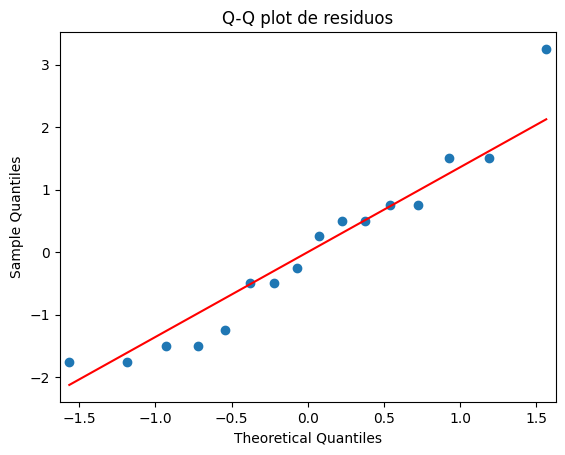

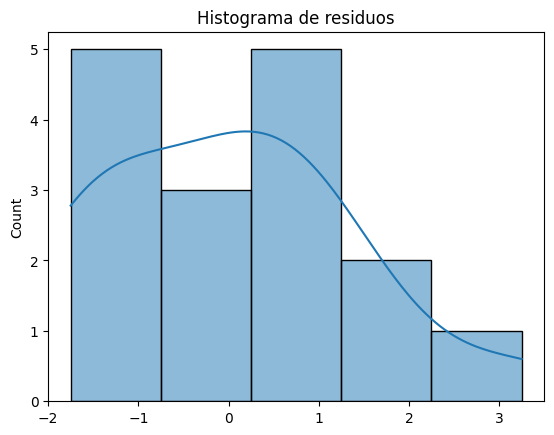

In [4]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [5]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import levene

#Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['Metodo'] == 'A']['Tiempo']
grupo2 = df[df['Metodo'] == 'B']['Tiempo']
grupo3 = df[df['Metodo'] == 'C']['Tiempo']
grupo4 = df[df['Metodo'] == 'D']['Tiempo']

stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")
if p < 0.05:
    print("Hay heterosedasticidad o Las varianzas no son iguales")
else:
    print("Hay homosedasticidad o Las varianzas son iguales")

#H0: Homoscedasticidad (varianzas iguales)
#H1: Heteroscedasticidad (varianzas diferentes)

p-valor de Levene: 0.4485146502776487
Hay homosedasticidad o Las varianzas son iguales


Lambda óptimo: -0.2809888705290132


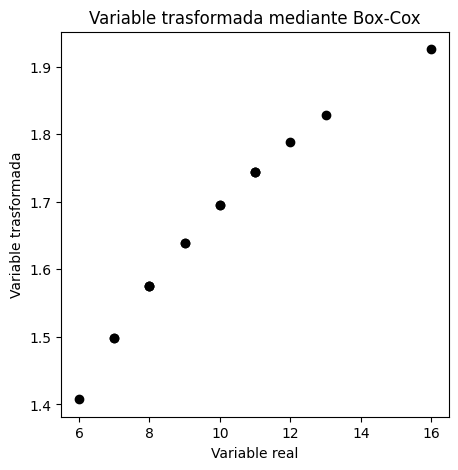

In [6]:
# Dayana Nathali Hernandez Hernandez

# Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0

df["Tiempo_boxcox"], lambda_opt = boxcox(df["Tiempo"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["Tiempo"], df["Tiempo_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [7]:
# Dayana Nathali Hernandez Hernandez

# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('Tiempo ~ C(Metodo)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Metodo),69.5,3.0,9.4237,0.0018
Residual,29.5,12.0,NaN,NaN


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B     1.25 0.6805 -2.0416 4.5416  False
     A      C      5.5 0.0016  2.2084 8.7916   True
     A      D     3.25 0.0533 -0.0416 6.5416  False
     B      C     4.25  0.011  0.9584 7.5416   True
     B      D      2.0 0.3181 -1.2916 5.2916  False
     C      D    -2.25 0.2309 -5.5416 1.0416  False
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

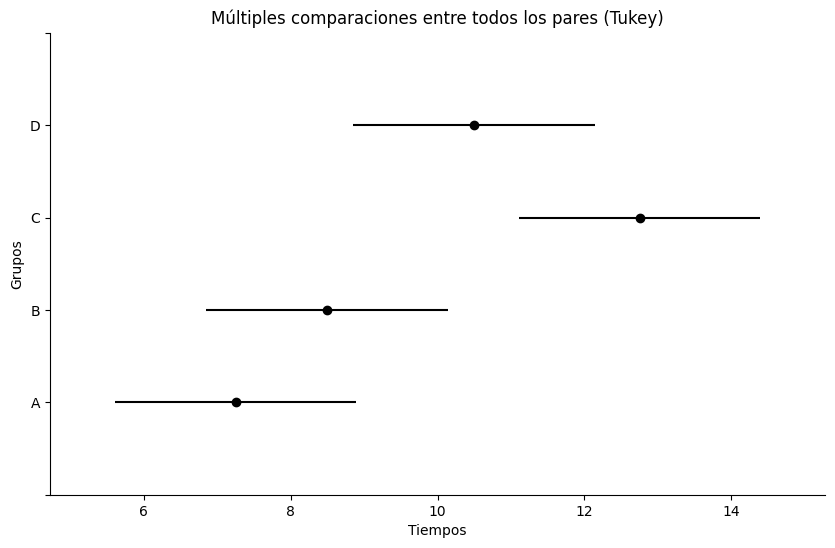

In [8]:
# Dayana Nathali Hernandez Hernandez

from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['Tiempo'], groups=df['Metodo'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Tiempos")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

Dayana Nathali Hernandez Hernandez

PROCEDIMIENTO
Primero se reviso si los datos cumplian con los supuestos necesarios para realizar al analisis y poder aplicar ANOVA, se verifico despues la normalidad de los residuos con la prueba de shapiro wilk y despues se comprobo que las varianzas fueran similares entre los grupos con la prueba de levene, como ambos suspuestos se cumplieron se realizo nuevamente el ANOVA para comparar sus tiempos de ensamble entre los 4 metodos y debido a que se encontraron diferencias significativas se aplico la prueba de Tukey para identificar entre que metodos existen esas diferencias

CONCLUSION
Los resultados muestran que le metodo de ensamble si influye en el tiempo que tarda el proceso, el metodo c presento los tiempos mas altos, mientras que el metodo A tuvo los tiempos mas bajos, ademas se encontraron diferencias importantes entre los metodos A Y C, y entre B Y C por lo que el merodo C resulta ser el menos eficiente.

2. **Comparación de cuatro tipos de cuero:** Un fabricante de calzado desea mejorar la calidad de las suelas, las cuales se pueden hacer con uno de los cuatro tipos de cuero A, B, C y D disponibles en el mercado. Para ello, prueba los cueros con una máquina que hace pasar los zapatos por una superficie abrasiva; la suela de éstos se desgasta al pasarla por dicha superficie. Como criterio de desgaste se usa la pérdida de peso después de un número fijo de ciclos. Se prueban en orden aleatorio 24 zapatos, seis de cada tipo de cuero. Al hacer las pruebas en orden completamente al azar se evitan sesgos y las mediciones en un tipo de cuero resultan independientes de las demás. Los datos (en miligramos) sobre el desgaste de cada tipo de cuero se muestran en la tabla.

| Tipo de cuero | Observaciones                  | Promedio |
|---------------|--------------------------------|----------|
| A             | 264, 260, 258, 241, 262, 255 | 256.7    |
| B             | 208, 220, 216, 200, 213, 206 | 209.8    |
| C             | 220, 263, 219, 225, 230, 228 | 230.8    |
| D             | 217, 226, 215, 227, 220, 222 | 220.7    |


In [9]:
# Dayana Nathali Hernandez Hernandez

import pandas as pd
from io import StringIO

datos = '''
Tipo,Valor
A,264
A,260
A,258
A,241
A,262
A,255
B,208
B,220
B,216
B,200
B,213
B,206
C,220
C,263
C,219
C,225
C,230
C,228
D,217
D,226
D,215
D,227
D,220
D,222
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,Tipo,Valor
0,A,264
1,A,260
2,A,258
3,A,241
4,A,262
5,A,255
6,B,208
7,B,220
8,B,216
9,B,200


In [10]:
# Dayana Nathali Hernandez Hernandez

from statsmodels.formula.api import ols
import statsmodels.api as sm

#Y ~ X
modelo_lineal = ols("Valor~C(Tipo)",data=df).fit()
tabla_anova= sm.stats.anova_lm(modelo_lineal)
tabla_anova

#Se rechaza hipotesis nula

,df,sum_sq,mean_sq,F,PR(>F)
C(Tipo),3.0,7019.458333,2339.819444,22.755356,0.000001
Residual,20.0,2056.500000,102.825000,NaN,NaN


In [11]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import shapiro
_, valor_p_sh= shapiro(modelo_lineal.resid)
print(f"valor-p de Shapiro: {valor_p_sh: 0.4f}/n")

#Se rechaza hipotesis nula
#ns=0.05

valor-p de Shapiro:  0.0097/n


Lambda óptimo: -3.707788382033557


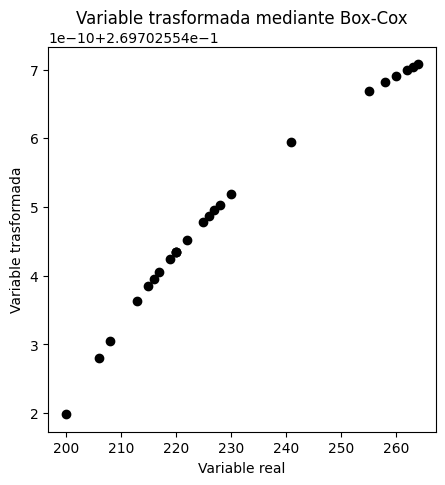

In [12]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0
df["observacion_boxcox"], lambda_opt = boxcox(df["Valor"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["Valor"], df["observacion_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [13]:
# Dayana Nathali Hernandez Hernandez

from statsmodels.formula.api import ols
import statsmodels.api as sm
modelo_lineal=ols(" observacion_boxcox ~ C(Tipo)", data=df).fit()
tabla_anova=sm.stats.anova_lm(modelo_lineal)
anova_p_value = tabla_anova['PR(>F)'][0]

if anova_p_value < 0.05:
  print("Se rechaza la hipótesis nula: Hay relación entre C(Tipo) y observacion_boxcox")
else:
  print("No se rechaza la hipótesis nula: No hay relación entre C(Tipo) y observacion_boxcox")
tabla_anova

Se rechaza la hipótesis nula: Hay relación entre C(Tipo) y observacion_boxcox


/tmp/ipykernel_37686/1847815841.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  anova_p_value = tabla_anova['PR(>F)'][0]


,df,sum_sq,mean_sq,F,PR(>F)
C(Tipo),3.0,3.735520e-19,1.245173e-19,23.368223,9.595693e-07
Residual,20.0,1.065698e-19,5.328489e-21,NaN,NaN


In [14]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['Tipo'] == 'A']['Valor']
grupo2 = df[df['Tipo'] == 'B']['Valor']
grupo3 = df[df['Tipo'] == 'C']['Valor']
grupo4 = df[df['Tipo'] == 'D']['Valor']

stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")


p-valor de Levene: 0.6351342635286297


In [15]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import levene

#Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['Tipo'] == 'A']['observacion_boxcox']
grupo2 = df[df['Tipo'] == 'B']['observacion_boxcox']
grupo3 = df[df['Tipo'] == 'C']['observacion_boxcox']
grupo4 = df[df['Tipo'] == 'D']['observacion_boxcox']

stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")
if p < 0.05:
    print("H1: Hay heterosedasticidad o Las varianzas no son iguales")
else:
    print("Ho:Hay homosedasticidad o Las varianzas son iguales")

p-valor de Levene: 0.3428159311494669
Ho:Hay homosedasticidad o Las varianzas son iguales


 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     A      B -46.1667    0.0  -62.553 -29.7803   True
     A      C -25.8333 0.0014 -42.2197   -9.447   True
     A      D    -35.5    0.0 -51.8863 -19.1137   True
     B      C  20.3333 0.0118    3.947  36.7197   True
     B      D  10.6667 0.2926  -5.7197   27.053  False
     C      D  -9.6667 0.3743  -26.053   6.7197  False
------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

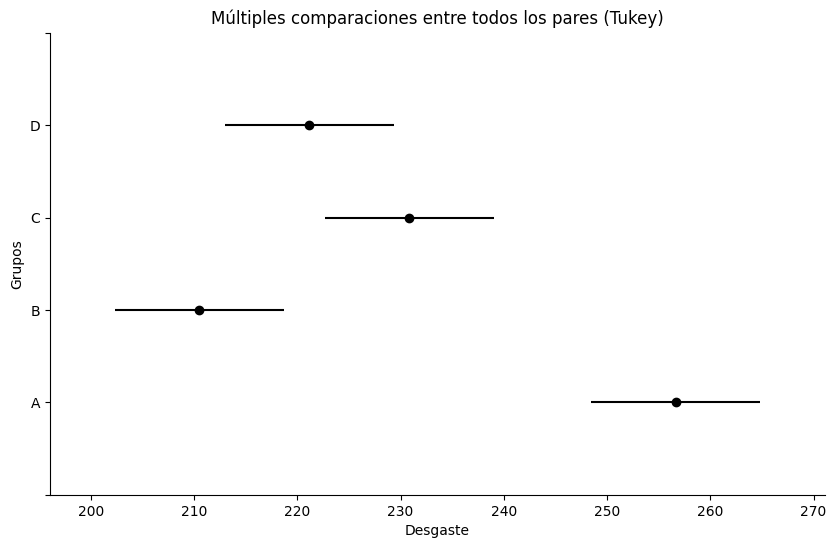

In [16]:
# Dayana Natahli Hernandez Hernandez

from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['Valor'], groups=df['Tipo'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Desgaste")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower upper reject
------------------------------------------------
     A      B     -0.0    0.0  -0.0  -0.0   True
     A      C     -0.0 0.0048  -0.0  -0.0   True
     A      D     -0.0 0.0001  -0.0  -0.0   True
     B      C      0.0 0.0018   0.0   0.0   True
     B      D      0.0 0.0613  -0.0   0.0  False
     C      D     -0.0  0.401  -0.0   0.0  False
------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

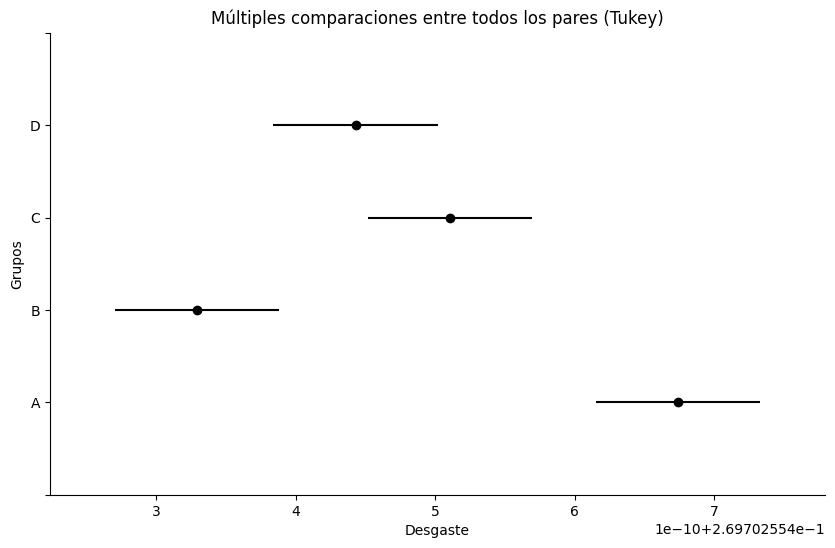

In [17]:
# Dayana Nathali Hernandez Hernandez


from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['observacion_boxcox'], groups=df['Tipo'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Desgaste")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

Dayana Nathali Hernandez Hernandez

PROCEDIMIENTO
Se verifico si los datos cumplian el suspuesto de normalidad, este supuesto nose cumplio inicialmente, se aplico una transformacion de Box-Cox para mejorar el comportamiento de los datos, despues se reviso la igualdad de varianzas mediante la prueba de levene, uab vez que los suspuestos fueron aceptables se pudo realizar el ANOVA para analizar si existian diferencias entre los tipos de cueros para despues aplicar la prueba de Tukey y identificar cuales eran diferentes entre si.

CONCLUSION
Se encontro que el tipo de cuero si afecta significativamente el desgaste de las suelas, el cuero B presento el mayor desgaste promedio, mientras que el cuero A mostro el mayor desgaste, por lo tanto, el tercero B seria la mejor opcion si se busca una mayor resistencia al desgaste.

3. En un centro de investigación se realiza un estudio para comparar varios tratamientos que, al aplicarse previamente a los frijoles crudos, reducen su tiempo de cocción. Estos tratamientos son a base de bicarbonato de sodio y cloruro de sodio o sal común. El primer tratamiento ($T_1$) es el de control, que consiste en no aplicar ningún tratamiento. El tratamiento $T_2$ es el remojo en agua con bicarbonato de sodio, el $T_3$ es remojar en agua con sal común y el $T_4$ es remojar en agua con una combinación de ambos ingredientes en proporciones iguales. La variable de respuesta es el tiempo de cocción en minutos. Los datos se muestran en la siguiente tabla:

| $T_1$ | $T_2$  | $T_3$  | $T_4$  |
|---------|-----|-----|-----|
| 213     | 76  | 57  | 84  |
| 214     | 85  | 67  | 82  |
| 204     | 74  | 55  | 85  |
| 208     | 78  | 64  | 92  |
| 212     | 82  | 61  | 87  |
| 200     | 75  | 63  | 79  |
| 207     | 82  | 63  | 90  |



In [18]:
# Dayana Nathali Hernandez Hernandez

import pandas as pd
from io import StringIO

datos = '''
Tratamiento,Tiempo
T1,213
T1,214
T1,204
T1,208
T1,212
T1,200
T1,207
T2,76
T2,85
T2,74
T2,78
T2,82
T2,75
T2,82
T3,57
T3,67
T3,55
T3,64
T3,61
T3,63
T3,63
T4,84
T4,82
T4,85
T4,92
T4,87
T4,79
T4,90
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df


,Tratamiento,Tiempo
0,T1,213
1,T1,214
2,T1,204
3,T1,208
4,T1,212
5,T1,200
6,T1,207
7,T2,76
8,T2,85
9,T2,74


In [19]:
# Dayana Nathali Hernandez Hernandez

# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('Tiempo ~ C(Tratamiento)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Tratamiento),95041.2500,3.0,1558.966,0.0
Residual,487.7143,24.0,NaN,NaN


In [20]:
# Dayana Nathali Hernandez Hernandez

residuales = modelo.resid

valor-p (Shapiro) = 0.34689165649616827


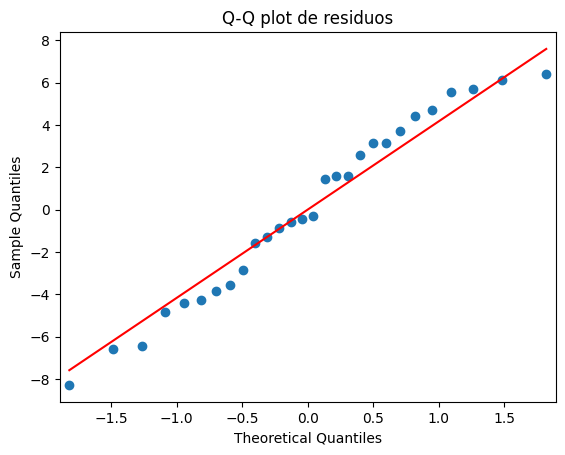

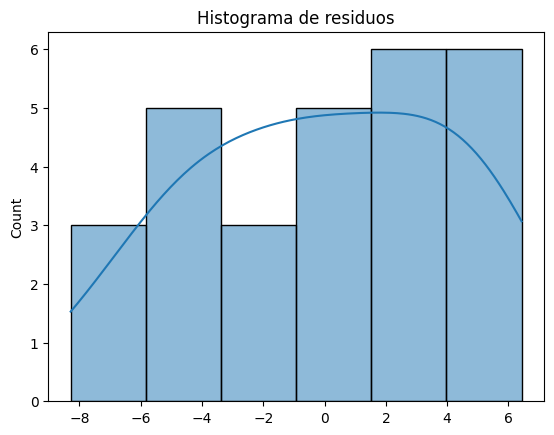

In [21]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [22]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import levene

#Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['Tratamiento'] == 'T1']['Tiempo']
grupo2 = df[df['Tratamiento'] == 'T2']['Tiempo']
grupo3 = df[df['Tratamiento'] == 'T3']['Tiempo']
grupo4 = df[df['Tratamiento'] == 'T4']['Tiempo']

stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")
if p < 0.05:
    print("Hay heterosedasticidad o Las varianzas no son iguales")
else:
    print("Hay homosedasticidad o Las varianzas son iguales")

#Ho: Homoscedasticidad
#H1: Heterosedasticidad
#0.05
#Valor p de 0.9201
#Se acepta hipotesis nula por lo tanto hay homocedasticidad

p-valor de Levene: 0.9201477397132211
Hay homosedasticidad o Las varianzas son iguales


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
    T1     T2 -129.4286    0.0 -136.0757 -122.7815   True
    T1     T3 -146.8571    0.0 -153.5043   -140.21   True
    T1     T4 -122.7143    0.0 -129.3614 -116.0672   True
    T2     T3  -17.4286    0.0  -24.0757  -10.7815   True
    T2     T4    6.7143 0.0471    0.0672   13.3614   True
    T3     T4   24.1429    0.0   17.4957     30.79   True
---------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

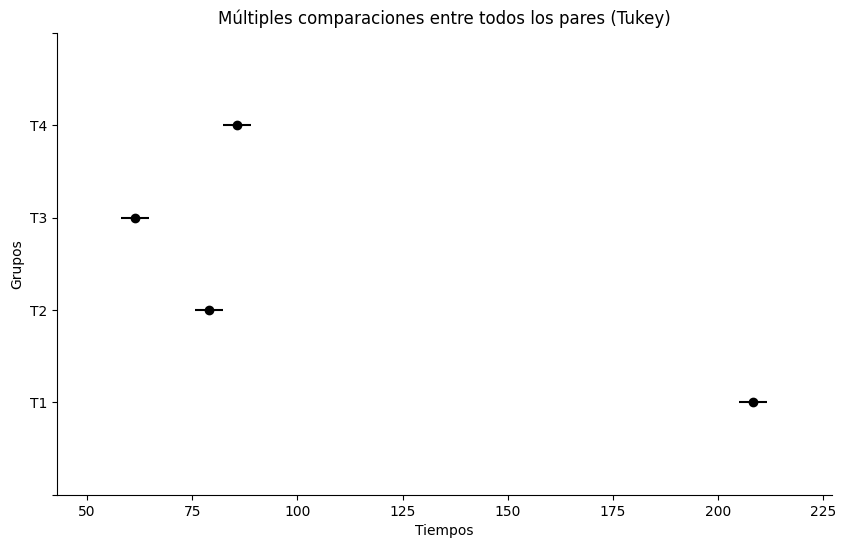

In [23]:
# Dayana Nathali Hernandez Hernandez

from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['Tiempo'], groups=df['Tratamiento'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Tiempos")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Test de Tukey\
# Es mejor cocerlos con Sal o T3

In [24]:
# Dayana Nathali Hernandez Hernandez

# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(Tratamiento)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.995


Dayana Nathali Hernandez

PROCEDIMIENTO
Primero se comprobo que los residuos pudieran seguir una distribucion normal y que las varianzas fueran similares entre los tratamientos, como ambos supuestos se cumplieron, se realizo el ANOVA para comparar los tiempos de coccion, despues se utilizo la prueba de tukey para determinar especificamente que tratamientos eran diferentes entre si.

CONCLUSION
Los tratamientos tuvieron un efecto importante sobre el tiempo de coccion de los frijoles, el tratamiento T3 que consistio en remojarlos con sal comun, fue el que logro los menores tiempos de coccion, por esta razon puede conciderarse la alternativa mas afectiva entre las opciones evaluadas

4. Para estudiar la confiabilidad de ciertos tableros electrónicos para carros, se someten a un envejecimiento acelerado durante 100 horas a determinada temperatura, y como variable de interés se mide la intensidad de corriente que circula entre dos puntos, cuyos valores aumentan con el deterioro. Se probaron 20 módulos repartidos de manera equitativa en cinco temperaturas y los resultados obtenidos fueron los siguientes:

| 20°C | 40°C | 60°C | 80°C | 100°C |
|------|------|------|------|-------|
| 15   | 17   | 23   | 28   | 45    |
| 18   | 21   | 19   | 32   | 51    |
| 13   | 11   | 25   | 34   | 57    |
| 12   | 16   | 22   | 31   | 48    |


In [25]:
# Dayana Nathali Hernandez Hernandez

import pandas as pd
from io import StringIO

datos = '''
Temperatura,Intensidad
20C,15
20C,18
20C,13
20C,12
40C,17
40C,21
40C,11
40C,16
60C,23
60C,19
60C,25
60C,22
80C,28
80C,32
80C,34
80C,31
100C,45
100C,51
100C,57
100C,48
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df


,Temperatura,Intensidad
0,20C,15
1,20C,18
2,20C,13
3,20C,12
4,40C,17
5,40C,21
6,40C,11
7,40C,16
8,60C,23
9,60C,19


In [26]:
# Dayana Nathali Hernandez Hernandez

from statsmodels.formula.api import ols
import statsmodels.api as sm

#Y ~ X
modelo_lineal = ols("Intensidad~C(Temperatura)",data=df).fit()
tabla_anova= sm.stats.anova_lm(modelo_lineal)
tabla_anova

#SI hay diferencia entre temperaturas

,df,sum_sq,mean_sq,F,PR(>F)
C(Temperatura),4.0,3411.8,852.950000,68.054521,1.963480e-09
Residual,15.0,188.0,12.533333,NaN,NaN


In [27]:
# Dayana Nathali Hernandez Hernandez
residuales = modelo.resid

valor-p (Shapiro) = 0.34689165649616827


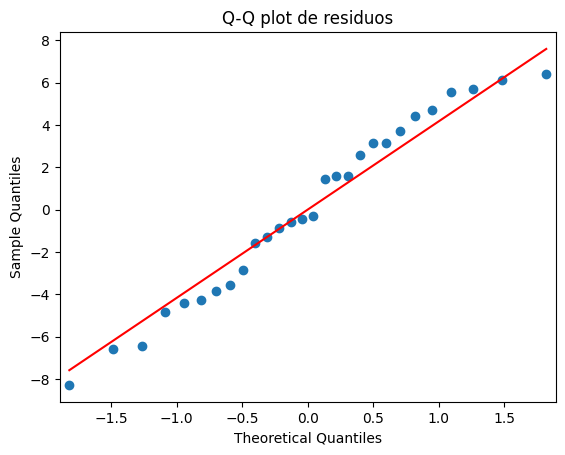

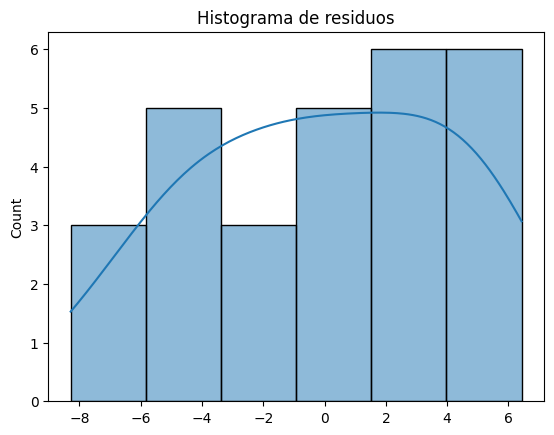

In [28]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [29]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import levene

#Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['Temperatura'] == '20C']['Intensidad']
grupo2 = df[df['Temperatura'] == '40C']['Intensidad']
grupo3 = df[df['Temperatura'] == '60C']['Intensidad']
grupo4 = df[df['Temperatura'] == '80C']['Intensidad']
grupo5 = df[df['Temperatura'] == '100C']['Intensidad']

stat, p = levene(grupo1, grupo2, grupo3, grupo4, grupo5)
print(f"p-valor de Levene: {p}")
if p < 0.05:
    print(" H1: Hay heterosedasticidad o Las varianzas no son iguales")
else:
    print(" Ho: Hay homosedasticidad o Las varianzas son iguales")

#Ho: Hay homoscedasticidad
#H1: Heterosedasticidad
#0.05
#Valor p es de 0.6159
# se rechaza la hipotesis alternativa y se acepta la hipotesis nula
#por lo tanto hay homocedasticidad

p-valor de Levene: 0.6159602096484009
 Ho: Hay homosedasticidad o Las varianzas son iguales


 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
  100C    20C   -35.75    0.0 -43.4801 -28.0199   True
  100C    40C    -34.0    0.0 -41.7301 -26.2699   True
  100C    60C    -28.0    0.0 -35.7301 -20.2699   True
  100C    80C    -19.0    0.0 -26.7301 -11.2699   True
   20C    40C     1.75 0.9535  -5.9801   9.4801  False
   20C    60C     7.75 0.0493   0.0199  15.4801   True
   20C    80C    16.75 0.0001   9.0199  24.4801   True
   40C    60C      6.0 0.1696  -1.7301  13.7301  False
   40C    80C     15.0 0.0002   7.2699  22.7301   True
   60C    80C      9.0 0.0191   1.2699  16.7301   True
------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

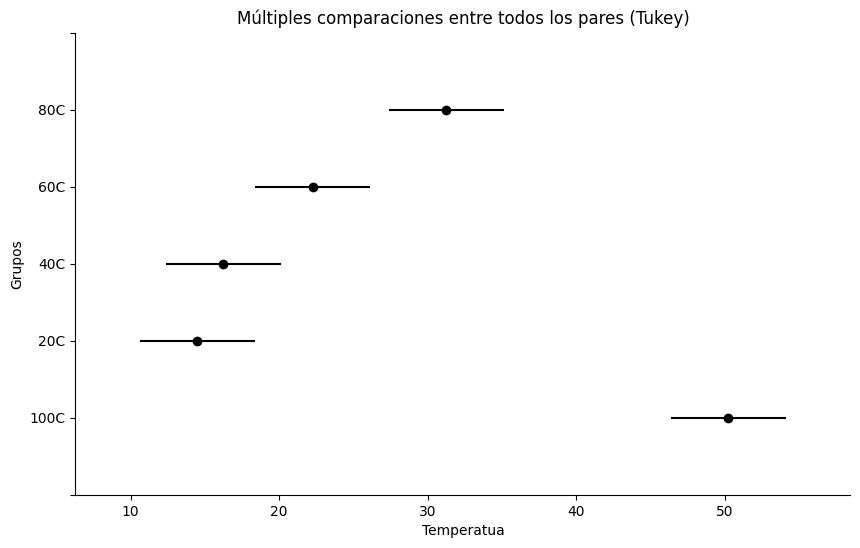

In [30]:
# Dayana Nathali Hernandez Hernandez

from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['Intensidad'], groups=df['Temperatura'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Temperatua")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [31]:
# Dayana Nathali Hernandez Hernandez

# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(Temperatura)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.948


In [32]:
# Dayana Hernandez Hernandez Hernandez

from scipy.stats import shapiro
_, valor_p_psh = shapiro(modelo_lineal.resid)
print("valor-p shapiro=", valor_p_psh)
if valor_p_psh<0.05:
  print("Los datos no siguen una distribucion normal")
else:
  print("Los datos siguen una distribucion normal \n")
#Ho:Hay normalidad en los residuales
#H1:No hay normalidad en los residuales
#0.55
#valor p es de 0.77
#por lo tanto se rechaza la hipotesis alternativa y hay normalidad en los residuales

valor-p shapiro= 0.7785351257478148
Los datos siguen una distribucion normal 



Dayana Nathali Hernandez Hernandez

PROCEDIMIENTO
Se verifico que los datos cumplieran con los supuestos de normalidad y homogeneidad de varianzas antes de ralizar el analisis, despues se aplico un ANOVA para comparar la intensidad de corriente obtenida a cada temperatura, finalmente se utilizo la prueba de Tukey patra identificar entre cuales temperaturas existian diferencias significativas.

CONCLUSION
La temperatura tuvo un efecto significativo sobre la intensidad de corriente, conforme aumento la temperatura tambien aumento la intensidad registrada, lo que indica un mayor deterioro de los modulos electronicos, los valores mas altos se observaron a 100 C, por lo que esta temperatura fue la que produjo mayor desgaste.

5. En una empresa de manufactura se propone un tratamiento para reducir el porcentaje de productos defectuosos. Para validar esta propuesta se diseñó un experimento en el que se producía con o sin la propuesta de mejora. Cada corrida experimental consistió en producir un lote y la variable de respuesta es el porcentaje de producto defectuoso. Se hicieron 25 réplicas para cada tratamiento. Los datos obtenidos se muestran a continuación:

| Tratamiento     | Porcentaje de producto defectuoso                                     |
|-----------------|----------------------------------------------------------------------|
| Con tratam.     | 5.3, 4.0, 4.0, 4.0, 2.6, 2.1, 5.1, 4.1, 4.1, 3.2, 5.1, 2.2, 4.1     |
| Sin tratam.     | 8.0, 13.2, 7.2, 8.2, 9.1, 6.7, 12.6, 16.3, 9.2, 6.4, 7.2, 17.2, 12.3 |


In [33]:
# Dayana Nathali Hernandez Hernandez

import pandas as pd
from io import StringIO

datos = '''Tratamiento,Porcentaje
CON,5.3
CON,4.0
CON,4.0
CON,4.0
CON,2.6
CON,2.1
CON,5.1
CON,4.1
CON,4.1
CON,3.2
CON,5.1
CON,2.2
CON,4.1
SIN,8.0
SIN,13.2
SIN,7.2
SIN,8.2
SIN,9.1
SIN,6.7
SIN,12.6
SIN,16.3
SIN,9.2
SIN,6.4
SIN,7.2
SIN,17.2
SIN,12.3
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,Tratamiento,Porcentaje
0,CON,5.3
1,CON,4.0
2,CON,4.0
3,CON,4.0
4,CON,2.6
5,CON,2.1
6,CON,5.1
7,CON,4.1
8,CON,4.1
9,CON,3.2


In [34]:
# Dayana Nathali Hernandez Hernndez

# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('Porcentaje~ C(Tratamiento)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Tratamiento),269.4496,1.0,37.1028,0.0
Residual,174.2938,24.0,NaN,NaN


In [35]:
# Dayana Nathali Hernandez Hernandez
residuales = modelo.resid

valor-p (Shapiro) = 0.08240142335256262


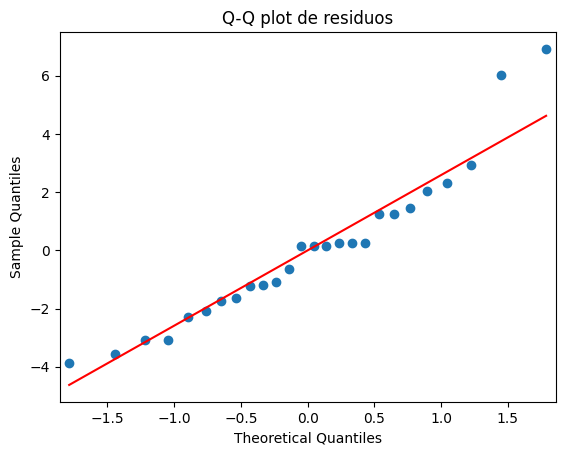

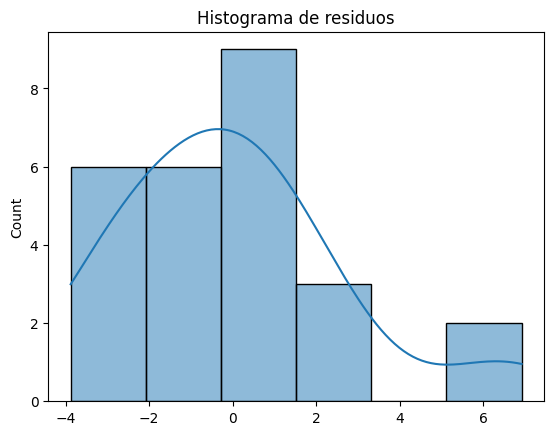

In [36]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [37]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['Tratamiento'] == 'CON']['Porcentaje']
grupo2 = df[df['Tratamiento'] == 'SIN']['Porcentaje']

stat, p = levene(grupo1, grupo2)
print(f"p-valor de Levene: {p}")

#Se rechaza la hipotesis nula, no hay homoscedasticidad

p-valor de Levene: 0.006953158590874458


Lambda óptimo: -0.05387226813423122


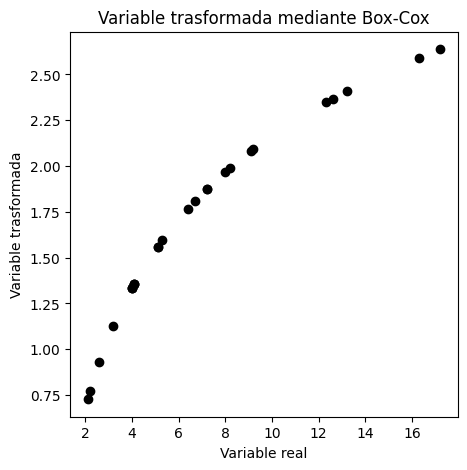

In [38]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0
df["Porcentaje_boxcox"], lambda_opt = boxcox(df["Porcentaje"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["Porcentaje"], df["Porcentaje_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

#Entre mas cerca este lambda de 1, mas literal es la interpretacion

In [39]:
# Dayana Nathali Hernandez Hernandez

from statsmodels.formula.api import ols
import statsmodels.api as sm

#Y ~ X
modelo_lineal = ols("Porcentaje_boxcox~C(Tratamiento)",data=df).fit()
tabla_anova= sm.stats.anova_lm(modelo_lineal)
tabla_anova

#Se rechaza hipotesis nula, tal menos un grupo es distinto

,df,sum_sq,mean_sq,F,PR(>F)
C(Tratamiento),1.0,5.040324,5.040324,58.843753,6.583032e-08
Residual,24.0,2.055745,0.085656,NaN,NaN


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper reject
------------------------------------------------
   CON    SIN   6.4385   0.0 4.2569  8.62   True
------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

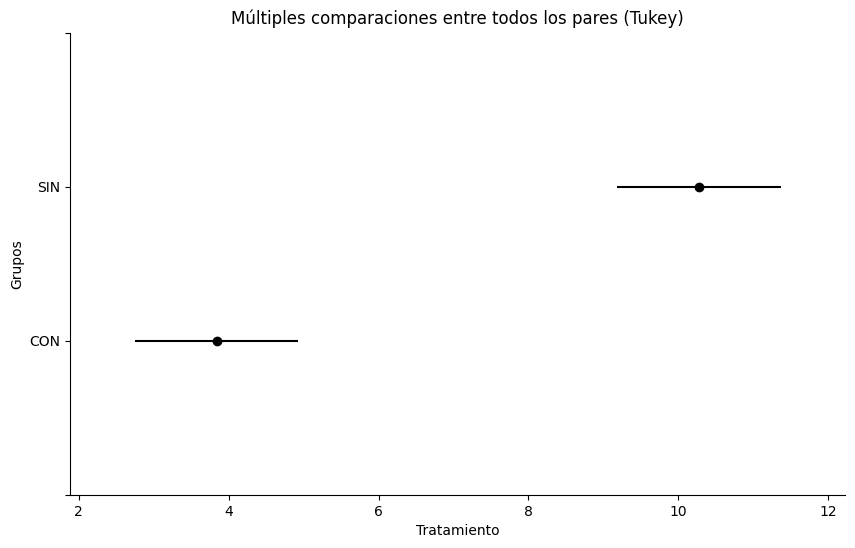

In [40]:
# Dayana Nathali Hernandez Hernandez

from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['Porcentaje'], groups=df['Tratamiento'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Tratamiento")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
   CON    SIN   0.8806   0.0 0.6437 1.1175   True
-------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

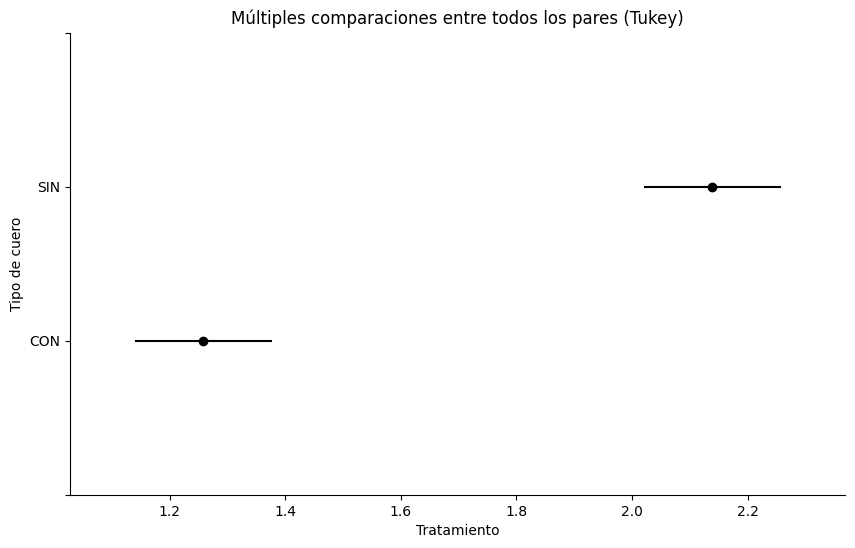

In [41]:
# Dayana Nathali Hernandez Hernandez

from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['Porcentaje_boxcox'], groups=df['Tratamiento'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Tipo de cuero", xlabel="Tratamiento")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

#No hay diferencia significativa entre B y D

In [42]:
# Dayana Nathali Hernandez Hernandez

# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(Tratamiento)'] / tabla_anova['sum_sq'].sum()

print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.710


Dayana Nathali Hernandez Hernandez

PROCEDIMIENTO
Al revisar los supuestos se observó que los datos no cumplían completamente con la normalidad ni con la igualdad de varianzas, por esta razón se aplicó una transformación Box-Cox para corregir estas condiciones,después se realizó nuevamente el análisis ANOVA, al encontrar diferencias significativas, se aplicó la prueba de Tukey para comparar los tratamientos.

CONCLUSION
Los resultados indican que el tratamiento propuesto sí ayuda a reducir el porcentaje de productos defectuosos. Los lotes que recibieron el tratamiento presentaron porcentajes considerablemente menores en comparación con los lotes sin tratamiento, por lo que la propuesta puede considerarse efectiva para mejorar la calidad del proceso.

6. Una compañía farmacéutica desea evaluar el efecto que tiene la cantidad de almidón en la dureza de las tabletas. Se decidió producir lotes con una cantidad determinada de almidón, y que las cantidades de almidón a aprobar fueran 2%, 5% y 10%. La variable de respuesta sería el promedio de la dureza de 20 tabletas de cada lote. Se hicieron 4 réplicas por tratamiento y se obtuvieron los siguientes resultados:

| % de almidón | Dureza               |
|--------------|----------------------|
| 2            | 4.3, 5.2, 4.8, 4.5  |
| 5            | 6.5, 7.3, 6.9, 6.1  |
| 10           | 9.0, 7.8, 8.5, 8.1  |


In [43]:
# Dayana Nathali Hernandez Hernandez

import pandas as pd
from io import StringIO

datos = '''Almidon,Dureza
2%,4.3
2%,5.2
2%,4.8
2%,4.5
5%,6.5
5%,7.3
5%,6.9
5%,6.1
10%,9.0
10%,7.8
10%,8.5
10%,8.1
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df


,Almidon,Dureza
0,2%,4.3
1,2%,5.2
2,2%,4.8
3,2%,4.5
4,5%,6.5
5,5%,7.3
6,5%,6.9
7,5%,6.1
8,10%,9.0
9,10%,7.8


In [44]:
# Dayana Nathali Hernandez Hernandez

from statsmodels.formula.api import ols
import statsmodels.api as sm
modelo_lineal=ols(" Dureza ~ C(Almidon)", data=df).fit()
tabla_anova=sm.stats.anova_lm(modelo_lineal)
if valor_p_psh<0.05:
  print("Ho: No hay relacion entre X y Y")
else:
  print("H1: Si hay relacion entre X y Y")
tabla_anova

H1: Si hay relacion entre X y Y


,df,sum_sq,mean_sq,F,PR(>F)
C(Almidon),2.0,26.726667,13.363333,58.101449,0.000007
Residual,9.0,2.070000,0.230000,NaN,NaN


In [45]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import shapiro
_, valor_p_psh = shapiro(modelo_lineal.resid)
print("valor-p shapiro=", valor_p_psh)
if valor_p_psh<0.05:
  print("Los datos no siguen una distribucion normal")
else:
  print("Los datos siguen una distribucion normal \n")
  #Se rechaza hipotesis nula
#ns=0.05

valor-p shapiro= 0.4295206808037123
Los datos siguen una distribucion normal 



In [46]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import levene

#Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['Almidon'] == '2%']['Dureza']
grupo2 = df[df['Almidon'] == '5%']['Dureza']
grupo3 =- df[df['Almidon'] == '10%']['Dureza']

stat, p = levene(grupo1, grupo2, grupo3)
print(f"p-valor de Levene: {p}")
if p < 0.05:
    print("Hay heterosedasticidad o Las varianzas no son iguales")
else:
    print("Hay homosedasticidad o Las varianzas son iguales")


p-valor de Levene: 0.771773370798543
Hay homosedasticidad o Las varianzas son iguales


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   10%     2%    -3.65    0.0 -4.5968 -2.7032   True
   10%     5%    -1.65 0.0023 -2.5968 -0.7032   True
    2%     5%      2.0 0.0006  1.0532  2.9468   True
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

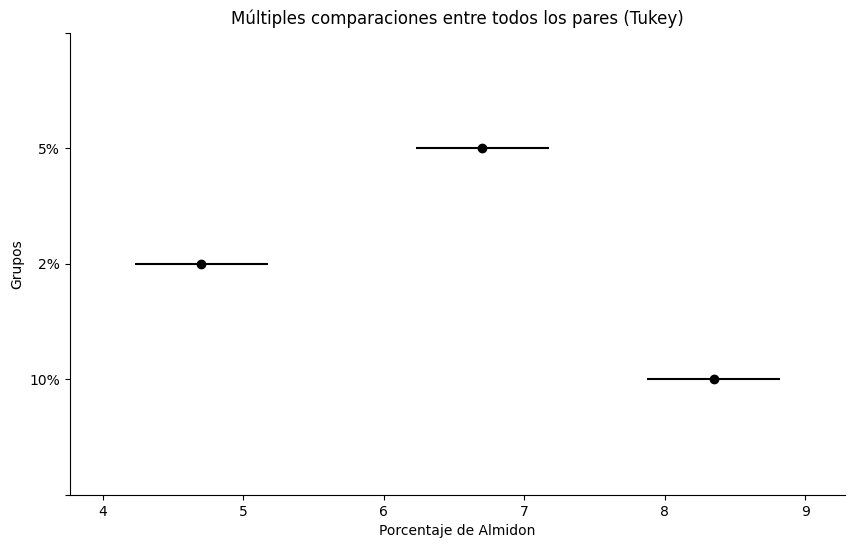

In [47]:
# Dayana Nathali Hernandez Hernandez

from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['Dureza'], groups=df['Almidon'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Porcentaje de Almidon")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [48]:
# Dayana Nathali Hernandez Hernandez

# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(Almidon)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")
#Tmanio del efecto, justifica el 94.8% de variabilidad

η² (tamaño de efecto): 0.928


Dayana Nathali Hernandez Hernandez

PROCEDIMIENTO
Se verificó primero que los residuos siguieran una distribución normal y que las varianzas fueran homogéneas entre los grupos. Como ambos requisitos se cumplieron, se realizó un ANOVA para comparar la dureza de las tabletas según el porcentaje de almidón utilizado. Después se aplicó la prueba de Tukey para identificar las diferencias entre cada concentración.

CONCLUSION
La cantidad de almidón utilizada influye directamente en la dureza de las tabletas. Se observó que al aumentar el porcentaje de almidón también aumentó la dureza. El mejor resultado se obtuvo con la concentración de 10 %, mientras que la de 2 % presentó la menor dureza.


7. Los datos que se presentan enseguida son rendimientos en toneladas por hectárea de un pasto con tres niveles de fertilización nitrogenada. El diseño fue completamente aleatorizado, con cinco repeticiones por tratamiento.

| Niveles de nitrógeno | Rendimientos (ton/ha)       |
|-----------------------|----------------------------|
| 1                     | 14.823, 14.676, 14.720, 14.5141, 15.065 |
| 2                     | 25.151, 25.401, 25.131, 25.031, 25.267 |
| 3                     | 32.605, 32.460, 32.256, 32.669, 32.111 |


In [49]:
# Dayana Nathali Hernandez Hernandez

import pandas as pd
from io import StringIO

datos = '''Nivel_nitrogeno,Rendimiento
nivel1,14.823
nivel1,14.676
nivel1,14.720
nivel1,14.5141
nivel1,15.065
nivel2,25.151
nivel2,25.401
nivel2,25.131
nivel2,25.031
nivel2,25.267
nivel3,32.605
nivel3,32.460
nivel3,32.256
nivel3,32.669
nivel3,32.111
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df


,Nivel_nitrogeno,Rendimiento
0,nivel1,14.8230
1,nivel1,14.6760
2,nivel1,14.7200
3,nivel1,14.5141
4,nivel1,15.0650
5,nivel2,25.1510
6,nivel2,25.4010
7,nivel2,25.1310
8,nivel2,25.0310
9,nivel2,25.2670


In [50]:
# Dayana Nathali Hernandez Hernandez

from statsmodels.formula.api import ols
import statsmodels.api as sm
modelo_lineal=ols(" Rendimiento ~ C(Nivel_nitrogeno)", data=df).fit()
tabla_anova=sm.stats.anova_lm(modelo_lineal)
if valor_p_psh<0.05:
  print("Ho: No hay relacion entre X y Y")
else:
  print("H1: Si hay relacion entre X y Y")
tabla_anova

H1: Si hay relacion entre X y Y


,df,sum_sq,mean_sq,F,PR(>F)
C(Nivel_nitrogeno),2.0,788.340773,394.170387,10131.619332,4.298250e-20
Residual,12.0,0.466860,0.038905,NaN,NaN


In [51]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import shapiro
_, valor_p_psh = shapiro(modelo_lineal.resid)
print("valor-p shapiro=", valor_p_psh)
if valor_p_psh<0.05:
  print("Los datos no siguen una distribucion normal")
else:
  print("Los datos siguen una distribucion normal \n")
#Se rechaza hipotesis nula
#ns=0.05

valor-p shapiro= 0.8890610190283172
Los datos siguen una distribucion normal 



In [52]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import levene
#Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['Nivel_nitrogeno'] == 'nivel1']['Rendimiento']
grupo2 = df[df['Nivel_nitrogeno'] == 'nivel2']['Rendimiento']
grupo3 = df[df['Nivel_nitrogeno'] == 'nivel3']['Rendimiento']

stat, p = levene(grupo1, grupo2, grupo3)
print(f"p-valor de Levene: {p}")
if p < 0.05:
    print("Hay heterosedasticidad o Las varianzas no son iguales")
else:
    print("Hay homosedasticidad o Las varianzas son iguales")

p-valor de Levene: 0.5977763142684792
Hay homosedasticidad o Las varianzas son iguales


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
nivel1 nivel2  10.4366   0.0 10.1038 10.7694   True
nivel1 nivel3  17.6606   0.0 17.3278 17.9934   True
nivel2 nivel3    7.224   0.0  6.8912  7.5568   True
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

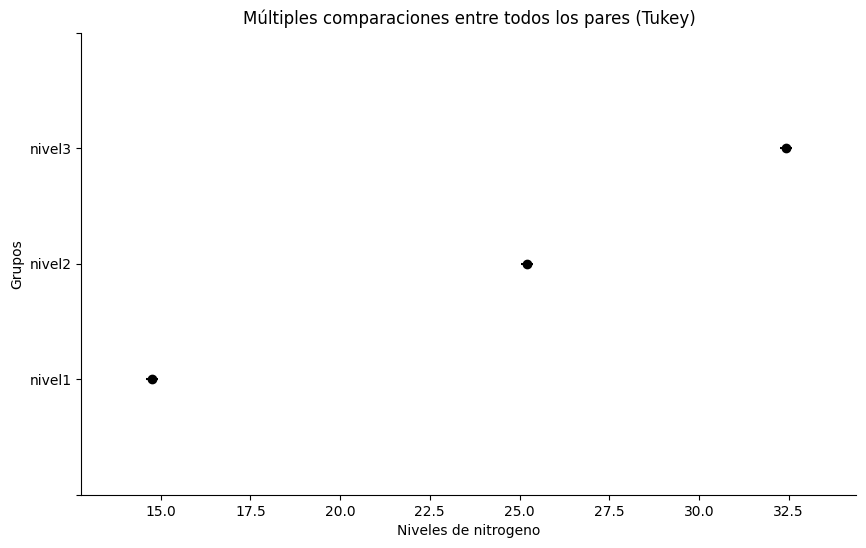

In [53]:
# Dayana Nathali Hernandez Hernandez

from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['Rendimiento'], groups=df['Nivel_nitrogeno'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Niveles de nitrogeno")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Test de Tukey\
# Es mejor cocerlos con Sal o T3

Dayana Nathali Hernandez Hernandez

PROCEDIMIENTO
Se comprobó que los datos cumplieran con los supuestos de normalidad y homogeneidad de varianzas, después se utilizó un ANOVA para analizar si los niveles de nitrógeno influían en el rendimiento del pasto, finalmente, se aplicó la prueba de Tukey para comparar cada nivel de nitrógeno con los demás.

CONCLUSION
Los niveles de nitrógeno tuvieron un efecto muy importante sobre el rendimiento, a medida que aumentó la cantidad de nitrógeno, también aumentó la producción del pasto, el nivel 3 obtuvo el mejor rendimiento, seguido del nivel 2 y finalmente del nivel 1


8. Un químico del departamento de desarrollo de un laboratorio farmacéutico desea conocer cómo influye el tipo de aglutinante utilizado en tabletas de ampicilina de 500 mg en el porcentaje de friabilidad; para ello, se eligen los siguientes aglutinantes: polivinilpirrolidona (PVP), carboximetilcelulosa sódica (CMC) y grenetina (Gre). Los resultados del diseño experimental son los siguientes:

| Aglutinante | % de friabilidad          |
|-------------|---------------------------|
| PVP         | 0.485, 0.250, 0.073, 0.205, 0.161 |
| CMC         | 9.64, 9.37, 9.53, 9.86, 9.79       |
| Gre         | 0.289, 0.275, 0.612, 0.152, 0.137  |


In [54]:
# Dayana Nathali Hernandez Hernandez

import pandas as pd
from io import StringIO

datos = '''Aglutinante,Friabilidad
PVP,0.485
PVP,0.250
PVP,0.073
PVP,0.205
PVP,0.161
CMC,9.64
CMC,9.37
CMC,9.53
CMC,9.86
CMC,9.79
Gre,0.289
Gre,0.275
Gre,0.612
Gre,0.152
Gre,0.137
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df


,Aglutinante,Friabilidad
0,PVP,0.485
1,PVP,0.250
2,PVP,0.073
3,PVP,0.205
4,PVP,0.161
5,CMC,9.640
6,CMC,9.370
7,CMC,9.530
8,CMC,9.860
9,CMC,9.790


In [55]:
# Dayana Nathali Hernandez Hernandez

from statsmodels.formula.api import ols
import statsmodels.api as sm
modelo_lineal=ols(" Friabilidad ~ C(Aglutinante)", data=df).fit()
tabla_anova=sm.stats.anova_lm(modelo_lineal)
if valor_p_psh<0.05:
  print("Ho: No hay relacion entre X y Y")
else:
  print("H1: Si hay relacion entre X y Y")
tabla_anova
#

H1: Si hay relacion entre X y Y


,df,sum_sq,mean_sq,F,PR(>F)
C(Aglutinante),2.0,292.920971,146.460485,4420.972597,6.198213e-18
Residual,12.0,0.397543,0.033129,NaN,NaN


In [56]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import shapiro
_, valor_p_psh = shapiro(modelo_lineal.resid)
print("valor-p shapiro=", valor_p_psh)
if valor_p_psh<0.05:
  print("Los datos no siguen una distribucion normal")
else:
  print("Los datos siguen una distribucion normal \n")
#Se rechaza hipotesis nula
#ns=0.05

valor-p shapiro= 0.42143454193876007
Los datos siguen una distribucion normal 



In [57]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import levene
grupo1 = df[df['Aglutinante'] == 'PVP']['Friabilidad']
grupo2 = df[df['Aglutinante'] == 'CMC']['Friabilidad']
grupo3 = df[df['Aglutinante'] == 'Gre']['Friabilidad']

stat, p = levene(grupo1, grupo2, grupo3)
print(f"p-valor de Levene: {p}")
if p < 0.05:
    print("Hay heterosedasticidad o Las varianzas no son iguales")
else:
    print("Hay homosedasticidad o Las varianzas son iguales")

p-valor de Levene: 0.8018412374552168
Hay homosedasticidad o Las varianzas son iguales


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
   CMC    Gre   -9.345   0.0 -9.6521 -9.0379   True
   CMC    PVP  -9.4032   0.0 -9.7103 -9.0961   True
   Gre    PVP  -0.0582  0.87 -0.3653  0.2489  False
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

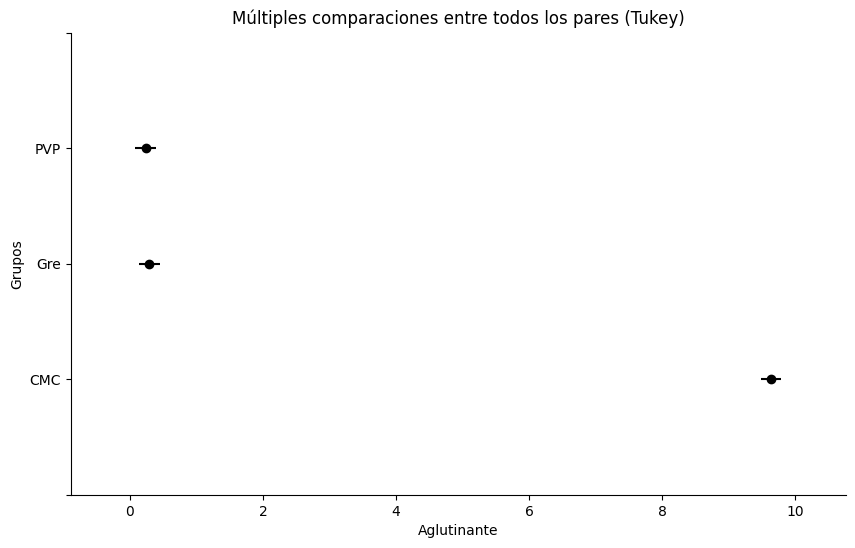

In [58]:
# Dayana Nathali Hernandez Hernandez

from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['Friabilidad'], groups=df['Aglutinante'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Aglutinante")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Test de Tukey\
# Es mejor cocerlos con Sal o T3

In [59]:
# Dayana Nathali Hernandez Hernandez

# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(Aglutinante)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.999


Dayana Nathali Hernandez Hernnandez

PROCEDIMIENTO
Antes de realizar el ANOVA se verificó la normalidad y la igualdad de varianzas entre los grupos, al cumplirse ambos supuestos, se realizó el análisis para determinar si el tipo de aglutinante tenía efecto sobre la friabilidad de las tabletas, después se aplicó la prueba de Tukey para identificar qué aglutinantes presentaban diferencias.

CONCLUSION
El tipo de aglutinante sí afecta la friabilidad de las tabletas. El aglutinante CMC presentó un comportamiento diferente al de los otros dos materialeS, en cambio, entre PVP y grenetina no se encontraron diferencias significativas, por lo que ambos pueden considerarse similares en cuanto a friabilidad.

9. Se cultivaron cuatro diferentes clonas de *agave tequilana* bajo un mismo esquema de manejo. Se quiere saber qué clona es la que responde mejor a dicho manejo, evaluando el nivel de respuesta con el porcentaje de azúcares reductores totales en base húmeda. Los datos se muestran a continuación:

| Clona | Porcentaje de azúcares reductores totales |
|-------|------------------------------------------|
| 1     | 8.69, 6.68, 6.83, 6.43, 10.30            |
| 2     | 8.00, 16.41, 12.43, 10.99, 15.53         |
| 3     | 17.39, 13.73, 15.62, 17.05, 15.42        |
| 4     | 10.37, 9.16, 8.83, 4.40, 10.38           |


In [60]:
# Dayana Nathali Hernandez Hernandez

import pandas as pd
from io import StringIO

datos = '''Clona,Azucares_reductores
1,8.69
1,6.68
1,6.83
1,6.43
1,10.30
2,8.00
2,16.41
2,12.43
2,10.99
2,15.53
3,17.39
3,13.73
3,15.62
3,17.05
3,15.42
4,10.37
4,9.16
4,8.83
4,4.40
4,10.38
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df


,Clona,Azucares_reductores
0,1,8.69
1,1,6.68
2,1,6.83
3,1,6.43
4,1,10.30
5,2,8.00
6,2,16.41
7,2,12.43
8,2,10.99
9,2,15.53


In [61]:
# Dayana Nathali Hernandez Hernandez

from statsmodels.formula.api import ols
import statsmodels.api as sm
modelo_lineal=ols(" Azucares_reductores ~ C(Clona)", data=df).fit()
tabla_anova=sm.stats.anova_lm(modelo_lineal)
if valor_p_psh<0.05:
  print("Ho: No hay relacion entre X y Y")
else:
  print("H1: Si hay relacion entre X y Y")
tabla_anova

H1: Si hay relacion entre X y Y


,df,sum_sq,mean_sq,F,PR(>F)
C(Clona),3.0,209.90716,69.969053,12.327073,0.000198
Residual,16.0,90.81676,5.676048,NaN,NaN


In [62]:
# Dayana Nathali Hernandez

from scipy.stats import levene
grupo1 = df[df['Clona'] == 1]['Azucares_reductores']
grupo2 = df[df['Clona'] == 2]['Azucares_reductores']
grupo3 = df[df['Clona'] == 3]['Azucares_reductores']
grupo4 = df[df['Clona'] == 4]['Azucares_reductores']

stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")
if p < 0.05:
    print("Hay heterosedasticidad o Las varianzas no son iguales")
else:
    print("Hay homosedasticidad o Las varianzas son iguales")


p-valor de Levene: 0.4290096340206233
Hay homosedasticidad o Las varianzas son iguales


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2    4.886 0.0237   0.575  9.197   True
     1      3    8.056 0.0003   3.745 12.367   True
     1      4    0.842 0.9428  -3.469  5.153  False
     2      3     3.17 0.1939  -1.141  7.481  False
     2      4   -4.044 0.0699  -8.355  0.267  False
     3      4   -7.214  0.001 -11.525 -2.903   True
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

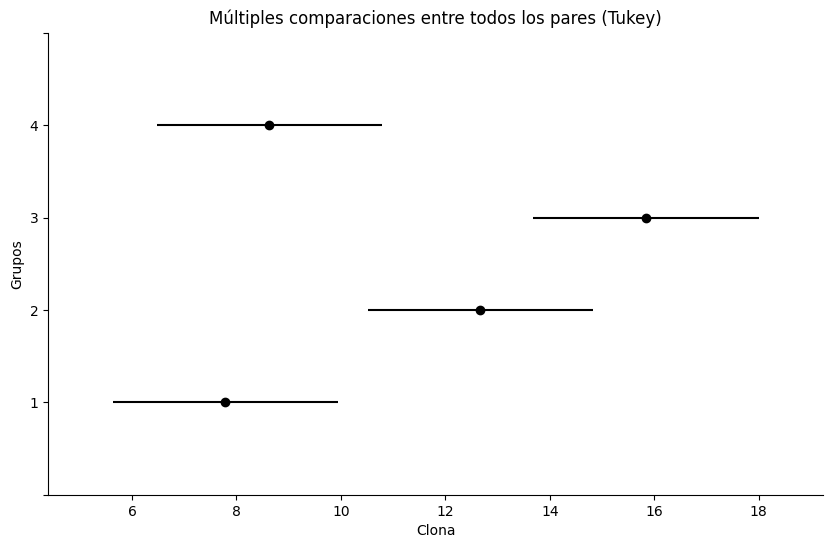

In [63]:
# Dayana Nathali Hernandez Hernandez

from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['Azucares_reductores'], groups=df['Clona'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Clona")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Test de Tukey\
# Es mejor cocerlos con Sal o T3


In [64]:
# Dayana Nathali Hernandez Hernandez

# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(Clona)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.698


Dayana Nathali Hernandez Hernandez

PROCEDIMIENTO
Se revisó que las varianzas fueran similares entre las diferentes clonas mediante la prueba de Levene, posteriormente se realizó el ANOVA para evaluar si existían diferencias en el porcentaje de azúcares reductores, como se encontraron diferencias significativas, se utilizó la prueba de Tukey para identificar qué clonas eran diferentes entre sí.

CONCLUSIONES
Las clonas evaluadas no respondieron de la misma manera. La clona 3 obtuvo los valores más altos de azúcares reductores, por lo que mostró el mejor desempeño dentro del estudio en contraste, las clonas 1 y 4 presentaron los valores más bajos, esto indica que la elección de la clona puede influir considerablemente en la cantidad de azúcares obtenidos.


10. Uno de los defectos que causan mayor desperdicio en la manufactura de discos ópticos compactos son los llamados “cometas”. Típicamente, se trata de una partícula que opone resistencia al fluido en la etapa de entintado. Se quiere comprobar de manera experimental la efectividad de un tratamiento de limpieza de partículas que está basado en fuerza centrípeta y aire ionizado. A 12 lotes de 50 CD se les aplica el tratamiento y a otros 12 lotes no se les aplica; en cada caso se mide el porcentaje de discos que presentan cometas, los resultados son los siguientes:

| Con tratamiento      | Sin tratamiento      |
|----------------------|----------------------|
| 5.30   | 8.02  |
| 4.03   | 13.18 |
| 4.00   | 7.15  |
| 2.56   | 9.11  |
| 5.06   | 8.23  |
| 4.06   | 16.3  |
| 2.08   | 9.20  |
| 4.03   | 6.35  |
| 2.04   | 7.15  |
| 1.18   | 8.66  |


In [65]:
# Dayana Hernandez Hernandez Hernandez

import pandas as pd
from io import StringIO

datos = '''Tratamiento,Valor
con,5.30
con,4.03
con,4.00
con,2.56
con,5.06
con,4.06
con,2.08
con,4.03
con,2.04
con,1.18
sin,8.02
sin,13.18
sin,7.15
sin,9.11
sin,8.23
sin,16.3
sin,9.20
sin,6.35
sin,7.15
sin,8.66
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df


,Tratamiento,Valor
0,con,5.30
1,con,4.03
2,con,4.00
3,con,2.56
4,con,5.06
5,con,4.06
6,con,2.08
7,con,4.03
8,con,2.04
9,con,1.18


In [66]:
# Dayana Nathali Hernandez Hernandez

residuales = modelo.resid

In [67]:
# Dayana Nathali Hernandez Hernandez

# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('Valor ~ C(Tratamiento)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Tratamiento),174.1090,1.0,30.6057,0.0
Residual,102.3981,18.0,NaN,NaN


valor-p (Shapiro) = 0.08240142335256262


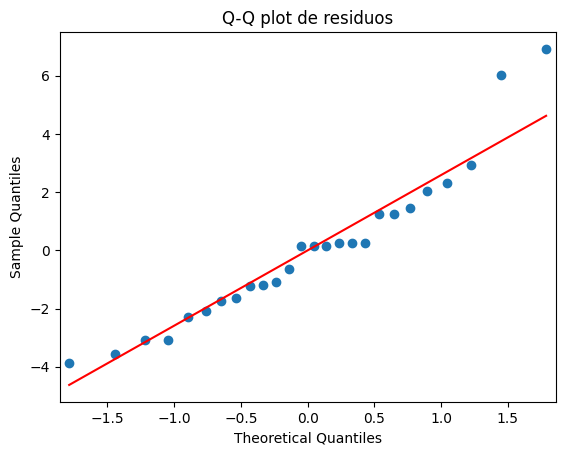

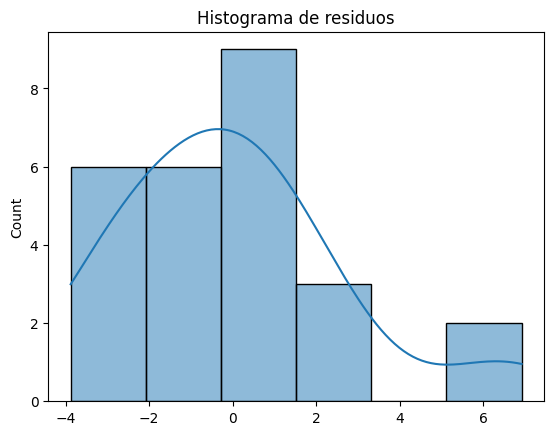

In [68]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [69]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import shapiro
_, valor_p_psh = shapiro(modelo_lineal.resid)
print("valor-p shapiro=", valor_p_psh)
if valor_p_psh<0.05:
  print("Los datos no siguen una distribucion normal")
else:
  print("Los datos siguen una distribucion normal \n")
  #Se rechaza hipotesis nula
#ns=0.05

valor-p shapiro= 0.7677173153296
Los datos siguen una distribucion normal 



In [70]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import levene
grupo1 = df[df['Tratamiento'] == 'con']['Valor']
grupo2 = df[df['Tratamiento'] == 'sin']['Valor']

stat, p = levene(grupo1, grupo2)
print(f"p-valor de Levene: {p}")
if p < 0.05:
    print("Hay heterosedasticidad o Las varianzas no son iguales")
else:
    print("Hay homosedasticidad o Las varianzas son iguales")



p-valor de Levene: 0.30433662983094306
Hay homosedasticidad o Las varianzas son iguales


Lambda óptimo: 0.32061169162391906


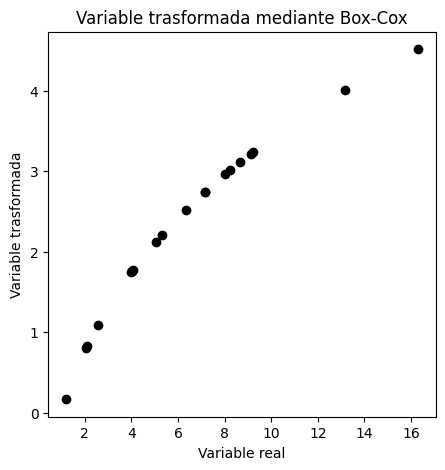

In [71]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0
df["porcentaje_boxcox"], lambda_opt = boxcox(df["Valor"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["Valor"], df["porcentaje_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

#Entre mas cerca este lambda de 1, mas literal es la interpretacion

In [72]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import shapiro
_, valor_p_sh= shapiro(modelo_lineal.resid)
print(f"valor-p de Shapiro: {valor_p_sh: 0.4f}/n")

#Se rechaza hipotesis nula
#ns=0.05

valor-p de Shapiro:  0.7677/n


In [73]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import levene
grupo1 = df[df['Tratamiento'] == 'con']['porcentaje_boxcox']
grupo2 = df[df['Tratamiento'] == 'sin']['porcentaje_boxcox']

stat, p = levene(grupo1, grupo2)
print(f"p-valor de Levene: {p}")
if p < 0.05:
    print("Hay heterosedasticidad o Las varianzas no son iguales")
else:
    print("Hay homosedasticidad o Las varianzas son iguales")



p-valor de Levene: 0.700897370037938
Hay homosedasticidad o Las varianzas son iguales


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower upper reject
-----------------------------------------------
   con    sin    5.901   0.0  3.66 8.142   True
-----------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

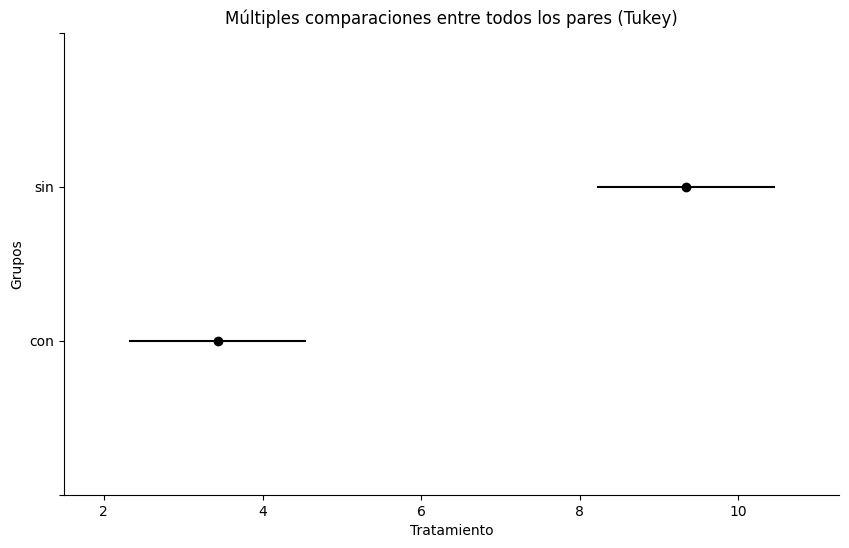

In [74]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['Valor'], groups=df['Tratamiento'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Tratamiento")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Test de Tukey\
# Es mejor cocerlos con Sal o T3



Dayana Nathali Hernandez Hernandez

PROCEDIMIENTO

Primero se revisó si los datos cumplían con los supuestos necesarios para realizar el análisi, se verificó la normalidad de los residuos mediante la prueba de Shapiro-Wilk y se obtuvo un valor p de 0.7677, indicando que los datos seguían una distribución normal, después se aplicó la prueba de Levene para comprobar que las varianzas fueran similares entre los lotes con tratamiento y sin tratamiento, obteniéndose un valor p de 0.3043, por lo que se consideró que existía homogeneidad de varianzas. También se aplicó una transformación Box-Cox para evaluar el comportamiento de los datos, obteniendo un valor de lambda de 0.3206, una vez verificados los supuestos, se realizó la comparación entre tratamientos y posteriormente la prueba de Tukey para identificar si existían diferencias significativas entre ambos grupos.

CONCLUSION

Los resultados muestran que el tratamiento de limpieza basado en fuerza centrípeta y aire ionizado sí tiene un efecto importante en la reducción de los defectos tipo "cometa", la prueba de Tukey encontró diferencias significativas entre los lotes con tratamiento y los lotes sin tratamiento, con una diferencia promedio de 5.901 puntos porcentuales, los lotes que recibieron el tratamiento presentaron una menor cantidad de discos defectuosos, por lo que se puede concluir que el tratamiento es efectivo y ayuda a mejorar la calidad del proceso de manufactura de los CDs.